# A Minimal Training Setup on NLB Maze

<html>
<img src="https://camo.githubusercontent.com/38004ff525c31b5088bbac056320ce63b4caaf23d8d0d5aea30b8cf7deba7b73/68747470733a2f2f746f7263682d627261696e2e72656164746865646f63732e696f2f656e2f6c61746573742f5f7374617469632f746f7263685f627261696e5f6c6f676f2e706e67", width="100px">
</html>


This example walks through a minimal training pipeline for decoding 2D hand velocity from motor cortex spiking activity, using the "jenkins_maze_train" recording from the [Neural Latents Benchmark (NLB)](https://neurallatents.github.io/) MC_Maze dataset.

It is intended as a starting point for new users of `torch_brain` and `brainsets`, and shows how to:
1. Build a custom `Dataset` on top of a `brainsets` recording.
2. Sample fixed-length trials around a behavioral event using `TrialSampler`.
3. Train one of three small decoders (a linear readout, a bidirectional GRU, or a dilated TCN).

> ⚠ **Note:**
> Although this notebook will run on a CPU, it is recommended that you use a GPU runtime.
> If you're on Google Colab, do: Runtime > Change runtime type > T4 GPU

## Setup

Install dependencies:

In [ ]:
!pip install scikit-learn 
!pip install torch git+https://github.com/neuro-galaxy/torch_brain

And preprocess the dataset using `brainsets`

In [ ]:
!brainsets prepare perich_miller_population_2018 --raw-dir data/raw --processed-dir data/processed

In [ ]:
import numpy as np

import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import Tensor, nn
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


class NDT(nn.Module):
    def __init__(
        self,
        hidden_dim: int,
        encoder_num_heads: int,
        encoder_ffn_factor: int,
        encoder_num_layers: int,
        dropout: float,
        num_units: int,
        ctx_window: float,
        bin_size: float,
        output_dim: int,
    ):
        super().__init__()

        num_bins = int(ctx_window / bin_size)
        self.position_emb = nn.Embedding(num_bins, hidden_dim)

        self.in_stitch = nn.Linear(num_units, hidden_dim, bias=False)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=encoder_num_heads,
            dim_feedforward=hidden_dim * encoder_ffn_factor,
            dropout=dropout,
            activation=nn.ReLU(),
            norm_first=True,
            batch_first=True,
        )
        self.encoder = nn.Sequential(
            nn.Dropout(dropout),
            nn.TransformerEncoder(
                encoder_layer=encoder_layer,
                num_layers=encoder_num_layers,
                norm=nn.LayerNorm(hidden_dim),
            ),
            nn.Dropout(dropout),
        )

        self.out_stitch = nn.Linear(hidden_dim, output_dim)

    def forward(self, spikes: torch.Tensor) -> torch.Tensor:
        B, T, N = spikes.size()
        dev = spikes.device
        spike_emb = self.in_stitch(spikes.float())  # (B, T, N) -> (B, T, D)

        positions = torch.arange(T, device=dev).unsqueeze(0).expand(B, -1)  # (B, T)
        positions_emb = self.position_emb(positions)  # (B, T) -> (B, T, D)

        emb = spike_emb + positions_emb  # (B, T, D)
        latent = self.encoder(emb)  # (B, T, D)

        out = self.out_stitch(latent)  # (B, T, D) -> (B, T, D_out)

        return out


model = NDT(
    hidden_dim=128,
    encoder_num_heads=8,
    encoder_ffn_factor=2,
    encoder_num_layers=4,
    dropout=0.1,
    num_units=71,
    ctx_window=1.0,
    bin_size=0.01,
    output_dim=2,
).to(device)

/home/aandre1/ws/torch_brain/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_992093/1341925751.py:46: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


Using device: cuda


Train: Number of recording: 1
Train: Number of training samples: 417
Val: Number of recording: 1
Val: Number of training samples: 60
Using device: cuda


  0%|          | 0/100 [00:00<?, ?it/s]

Val R²: 0.756: 100%|██████████| 100/100 [00:41<00:00,  2.42it/s]


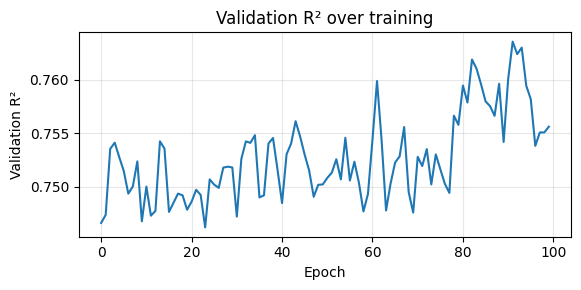

In [21]:
from torch_brain.datasets import PerichMillerPopulation2018, DatasetIndex
from torch_brain.utils.binning import bin_spikes
from torch.utils.data import DataLoader  # standard PyTorch loader

from torch_brain.samplers import RandomFixedWindowSampler, SequentialFixedWindowSampler
import matplotlib.pyplot as plt


class SimplePerichMillerPopulationDataset(PerichMillerPopulation2018):
    def __init__(self, root: str, bin_size: float):
        super().__init__(root=root, recording_ids=["c_20131003_center_out_reaching"])
        self.bin_size = bin_size

    def get_sampling_intervals(self, split=None):
        intervals = super().get_sampling_intervals()

        for rid, interval in intervals.items():
            recording = self.get_recording(rid)
            spikes_domain = recording.spikes.domain
            split_domain = recording.get_nested_attribute(f"{split}_domain")

            intervals[rid] = interval & spikes_domain & split_domain

        return intervals

    def __getitem__(self, index: DatasetIndex):
        data = super().__getitem__(index)

        X = bin_spikes(
            data.spikes, num_units=len(data.units), bin_size=self.bin_size, eps=1e-1
        )

        X = torch.from_numpy(X).float()

        Y = data.cursor.vel / 20.0
        Y = torch.from_numpy(Y).float()
        return X, Y


DATA_ROOT = "/home/aandre1/ws/torch_brain/data/processed"
bin_size = 0.01
BATCH_SIZE = 32

train_ds = SimplePerichMillerPopulationDataset(DATA_ROOT, bin_size=bin_size)
train_sampler = RandomFixedWindowSampler(
    sampling_intervals=train_ds.get_sampling_intervals(split="train"),
    window_length=1.0,
    drop_short=True,
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler)


val_ds = SimplePerichMillerPopulationDataset(DATA_ROOT, bin_size=bin_size)
val_sampler = SequentialFixedWindowSampler(
    sampling_intervals=train_ds.get_sampling_intervals(split="valid"),
    window_length=1.0,
    drop_short=True,
)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, sampler=val_sampler)


val_loader


print(f"Train: Number of recording: {len(train_ds.recording_ids)}")
print(f"Train: Number of training samples: {len(train_sampler)}")

print(f"Val: Number of recording: {len(val_ds.recording_ids)}")
print(f"Val: Number of training samples: {len(val_sampler)}")


# Hyperparameters (feel free to play with these)
BIN_SIZE = 0.01  # seconds
BATCH_SIZE = 32
EPOCHS = 100
LR = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


from sklearn.metrics import r2_score

optim = torch.optim.AdamW(model.parameters(), lr=LR)

val_r2_history = []

for _epoch in (epoch_pbar := tqdm(range(EPOCHS))):
    model.train()
    for X, Y in train_loader:
        X, Y = X.to(device), Y.to(device)
        pred = model(X)
        loss = nn.functional.mse_loss(pred, Y)
        optim.zero_grad()
        loss.backward()
        optim.step()

    with torch.no_grad():
        model.eval()
        preds, targets = [], []
        for X, Y in val_loader:
            X, Y = X.to(device), Y.to(device)
            preds.append(model(X))
            targets.append(Y)
        pred = torch.cat(preds).flatten(0, 1).cpu()
        target = torch.cat(targets).flatten(0, 1).cpu()
        r2 = r2_score(target, pred)
        val_r2_history.append(r2)
        epoch_pbar.set_description(f"Val R²: {r2:.3f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(val_r2_history)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation R²")
ax.set_title("Validation R² over training")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()